In [ ]:
import sys
import os
sys.path.append(os.path.abspath('..'))

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

from src.nn import CNNModel

In [2]:
# Transforsms the pixels of the image to tensors and normalizes them to the range [0, 1].
transform = transforms.Compose([transforms.ToTensor()])

# MNIST dataset: 60,000 training images and 10,000 test images of handwritten digits (0-9).
# batch_size = 64 means that the model will be updated after processing 64 images.
trainset = torchvision.datasets.MNIST(root = './data', train = True, download = True, transform = transform)
trainloader = torch.utils.data.DataLoader(trainset, batch_size = 64, shuffle = True)

testset = torchvision.datasets.MNIST(root = './data', train = False, download = True, transform = transform)
testloader = torch.utils.data.DataLoader(testset, batch_size = 64, shuffle = False)

print(f"Train images: {len(trainset)}")
print(f"Test images: {len(testset)}")

Train images: 60000
Test images: 10000


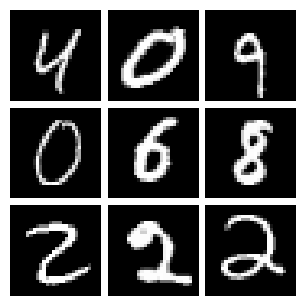

In [28]:
# We take one batch.
dataiter = iter(trainloader)
images, labels = next(dataiter)

# Number of images to show
fig, axes = plt.subplots(3, 3, figsize=(3, 3))

for i, ax in enumerate(axes.flat):
    # In pythorch we have [1,28,28] of shape but we need [28,28]
    img = images[i].squeeze()
    
    # Draw
    ax.imshow(img, cmap='gray')
    ax.axis('off')

plt.tight_layout(pad = 0.5)
plt.show()

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Training on device: {device}")

Training on device: cuda


In [ ]:
# We initialize the model.
model = CNNModel().to(device)

# CrossEntropyLoss is the standard loss function for classification problems. It includes a softmax.
cross_entropy = nn.CrossEntropyLoss()

# Adam is the standard optimization algorithm. Adapts the learning rate for each parameter based on the first and second moments of the gradients.
optimizer = optim.Adam(model.parameters(), lr = 0.001, weight_decay = 1e-5)

In [5]:
epochs = 3

for epoch in range(epochs):
    model.train()
    running_loss = 0.0

    for i, (inputs, labels) in enumerate(trainloader):
        inputs, labels = inputs.to(device), labels.to(device)

        # 1. Initialize the gradients to zero.
        optimizer.zero_grad()

        # 2. Forward pass.
        outputs = model(inputs)

        # 3. Calculate the loss (error).
        loss = cross_entropy(outputs, labels)

        # 4. Backward pass.
        loss.backward()

        # Optimization step (Actualize the weights).
        optimizer.step()

        running_loss += loss.item()

    print(f"Epoch {epoch + 1}, Loss: {running_loss / len(trainloader)}")

print("Finished Training!")

Epoch 1, Loss: 0.22371637361096358
Epoch 2, Loss: 0.06398752995375503
Epoch 3, Loss: 0.045221867718806326
Finished Training!


In [6]:
folder_path = os.path.join('..', 'models')
if not os.path.exists(folder_path): os.makedirs(folder_path)

model_name = 'mnist_cnn_v1.pth'
full_path = os.path.join(folder_path, model_name)

torch.save(model.state_dict(), full_path)

print(f"Model saved to {full_path}")

Model saved to ..\models\mnist_cnn_v1.pth


In [7]:
loaded_model = CNNModel().to(device)
loaded_model.load_state_dict(torch.load(full_path, map_location = device))

C:\Users\win11\AppData\Local\Temp\ipykernel_21676\3648737320.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  loaded_model.load_state_dict(torch.load(full_path, map_locat

<All keys matched successfully>

In [8]:
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for inputs, labels in testloader:
        inputs, labels = inputs.to(device), labels.to(device)

        # Prediction
        outputs = model(inputs)

        confidence, predictions = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predictions == labels).sum().item()

accuracy = 100 * correct / total
print(f"Accuracy on the test set: {accuracy:.2f}%")

Accuracy on the test set: 98.68%
